#  Diwali Sales & Customer Insights

## Project Overview

This project analyzes Diwali sales data to understand customer purchasing patterns, product performance, and sales trends.

The analysis focuses on identifying high-value customer segments, understanding purchasing behavior across different demographic groups, analyzing product categories, and comparing sales performance across states.

## Objectives


- Analyze overall sales and order performance
- Examine customer purchasing behavior across different genders and age groups
- Analyze sales patterns based on marital status and occupation
- Compare sales performance across different states and geographic zones
- Identify high-performing product categories and individual products
- Examine the relationship between customer age groups and product categories
- Identify customer segments and markets that contribute significantly to overall sales
- Generate meaningful business insights from the analyzed sales data

## Technologies Used

- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Jupyter Notebook

## Key Business Questions

1. How do sales and order volumes vary across different genders and age groups?
2. Which marital-status and occupational groups contribute the most to sales?
3. Which states and geographic zones generate the highest sales?
4. Which product categories and individual products perform best?
5. Which age groups show stronger purchasing patterns across different product categories?
6. Which customer segments contribute significantly to overall sales?
7. What business insights can be derived from the observed sales and purchasing patterns?

In [89]:
# import python libraries

import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns

In [90]:
# import csv file
df = pd.read_csv('Diwali Sales Data.csv', encoding= 'unicode_escape')

#  Data Preparation

Before performing the analysis, the dataset is loaded and prepared by examining its structure, identifying missing values, and cleaning unnecessary or incomplete data.

This step ensures that the dataset is suitable for further analysis and that the results are based on consistent and usable records.

In [91]:
df.shape

(11251, 15)

In [92]:
df.head()

,User_ID,Cust_name,Product_ID,Gender,Age Group,Age,Marital_Status,State,Zone,Occupation,Product_Category,Orders,Amount,Status,unnamed1
0,1002903,Sanskriti,P00125942,F,26-35,28,0,Maharashtra,Western,Healthcare,Auto,1,23952.0,NaN,NaN
1,1000732,Kartik,P00110942,F,26-35,35,1,Andhra Pradesh,Southern,Govt,Auto,3,23934.0,NaN,NaN
2,1001990,Bindu,P00118542,F,26-35,35,1,Uttar Pradesh,Central,Automobile,Auto,3,23924.0,NaN,NaN
3,1001425,Sudevi,P00237842,M,0-17,16,0,Karnataka,Southern,Construction,Auto,2,23912.0,NaN,NaN
4,1000588,Joni,P00057942,M,26-35,28,1,Gujarat,Western,Food Processing,Auto,2,23877.0,NaN,NaN


In [93]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 11251 entries, 0 to 11250
Data columns (total 15 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   User_ID           11251 non-null  int64  
 1   Cust_name         11251 non-null  str    
 2   Product_ID        11251 non-null  str    
 3   Gender            11251 non-null  str    
 4   Age Group         11251 non-null  str    
 5   Age               11251 non-null  int64  
 6   Marital_Status    11251 non-null  int64  
 7   State             11251 non-null  str    
 8   Zone              11251 non-null  str    
 9   Occupation        11251 non-null  str    
 10  Product_Category  11251 non-null  str    
 11  Orders            11251 non-null  int64  
 12  Amount            11239 non-null  float64
 13  Status            0 non-null      float64
 14  unnamed1          0 non-null      float64
dtypes: float64(3), int64(4), str(8)
memory usage: 1.3 MB


In [ ]:

df.drop(['Status', 'unnamed1'], axis=1, inplace=True, errors='ignore')

In [ ]:

pd.isnull(df).sum()

User_ID              0
Cust_name            0
Product_ID           0
Gender               0
Age Group            0
Age                  0
Marital_Status       0
State                0
Zone                 0
Occupation           0
Product_Category     0
Orders               0
Amount              12
dtype: int64

In [ ]:

df.dropna(inplace=True)

In [ ]:

df['Amount'] = df['Amount'].astype('int')

In [98]:
df['Amount'].dtypes

dtype('int64')

In [99]:
df.columns

Index(['User_ID', 'Cust_name', 'Product_ID', 'Gender', 'Age Group', 'Age',
       'Marital_Status', 'State', 'Zone', 'Occupation', 'Product_Category',
       'Orders', 'Amount'],
      dtype='str')

In [ ]:

df.rename(columns= {'Marital_Status':'Shaadi'})

,User_ID,Cust_name,Product_ID,Gender,Age Group,Age,Shaadi,State,Zone,Occupation,Product_Category,Orders,Amount
0,1002903,Sanskriti,P00125942,F,26-35,28,0,Maharashtra,Western,Healthcare,Auto,1,23952
1,1000732,Kartik,P00110942,F,26-35,35,1,Andhra Pradesh,Southern,Govt,Auto,3,23934
2,1001990,Bindu,P00118542,F,26-35,35,1,Uttar Pradesh,Central,Automobile,Auto,3,23924
3,1001425,Sudevi,P00237842,M,0-17,16,0,Karnataka,Southern,Construction,Auto,2,23912
4,1000588,Joni,P00057942,M,26-35,28,1,Gujarat,Western,Food Processing,Auto,2,23877
...,...,...,...,...,...,...,...,...,...,...,...,...,...
11246,1000695,Manning,P00296942,M,18-25,19,1,Maharashtra,Western,Chemical,Office,4,370
11247,1004089,Reichenbach,P00171342,M,26-35,33,0,Haryana,Northern,Healthcare,Veterinary,3,367
11248,1001209,Oshin,P00201342,F,36-45,40,0,Madhya Pradesh,Central,Textile,Office,4,213
11249,1004023,Noonan,P00059442,M,36-45,37,0,Karnataka,Southern,Agriculture,Office,3,206


In [ ]:

df.describe()

,User_ID,Age,Marital_Status,Orders,Amount
count,1.123900e+04,11239.000000,11239.000000,11239.000000,11239.000000
mean,1.003004e+06,35.410357,0.420055,2.489634,9453.610553
std,1.716039e+03,12.753866,0.493589,1.114967,5222.355168
min,1.000001e+06,12.000000,0.000000,1.000000,188.000000
25%,1.001492e+06,27.000000,0.000000,2.000000,5443.000000
50%,1.003064e+06,33.000000,0.000000,2.000000,8109.000000
75%,1.004426e+06,43.000000,1.000000,3.000000,12675.000000
max,1.006040e+06,92.000000,1.000000,4.000000,23952.000000


In [ ]:

df[['Age', 'Orders', 'Amount']].describe()

,Age,Orders,Amount
count,11239.000000,11239.000000,11239.000000
mean,35.410357,2.489634,9453.610553
std,12.753866,1.114967,5222.355168
min,12.000000,1.000000,188.000000
25%,27.000000,2.000000,5443.000000
50%,33.000000,2.000000,8109.000000
75%,43.000000,3.000000,12675.000000
max,92.000000,4.000000,23952.000000


# 📊 Overall Sales Performance

Before analyzing individual customer segments, we first look at the overall scale of the dataset.

# Overall KPIs

In [103]:
total_sales = df['Amount'].sum()
total_orders = df['Orders'].sum()
unique_customers = df['User_ID'].nunique()
unique_products = df['Product_ID'].nunique()

print("Total Sales:", total_sales)
print("Total Orders:", total_orders)
print("Unique Customers:", unique_customers)
print("Unique Products:", unique_products)

Total Sales: 106249129
Total Orders: 27981
Unique Customers: 3752
Unique Products: 2350


# Exploratory Data Analysis

# Customer Analysis

This section analyzes customer purchasing behavior across different demographic groups, including gender, age group, marital status, and occupation.

##  Gender Analysis

This analysis examines sales and order patterns across different customer genders.

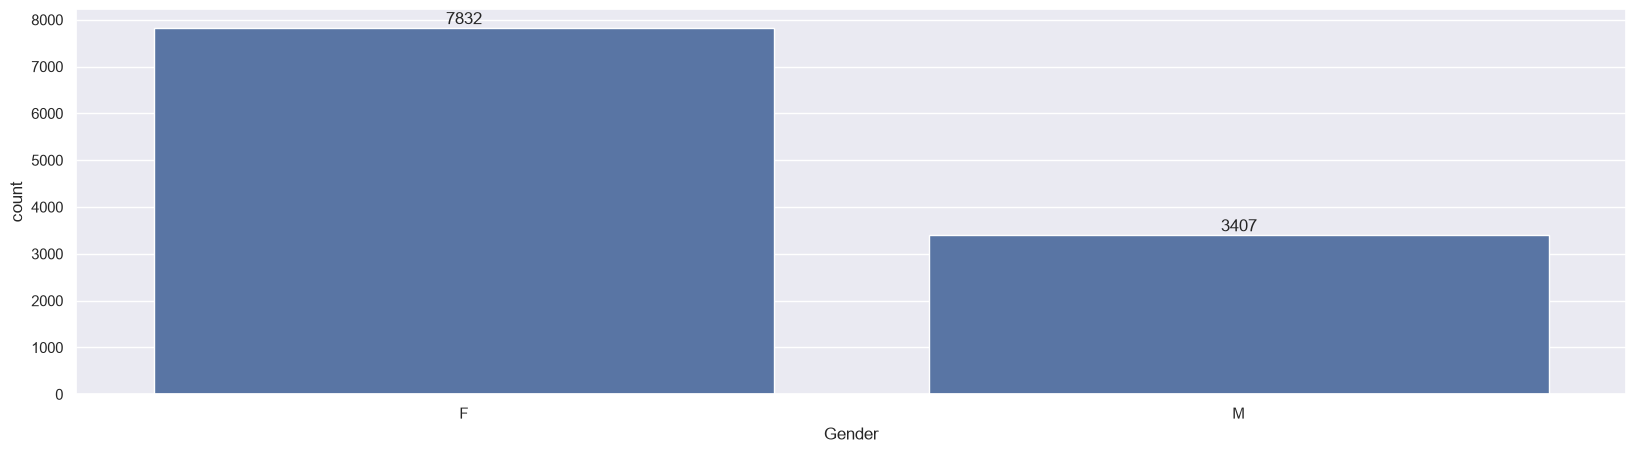

In [ ]:

ax = sns.countplot(x = 'Gender',data = df)

for bars in ax.containers:
    ax.bar_label(bars)

<Axes: xlabel='Gender', ylabel='Amount'>

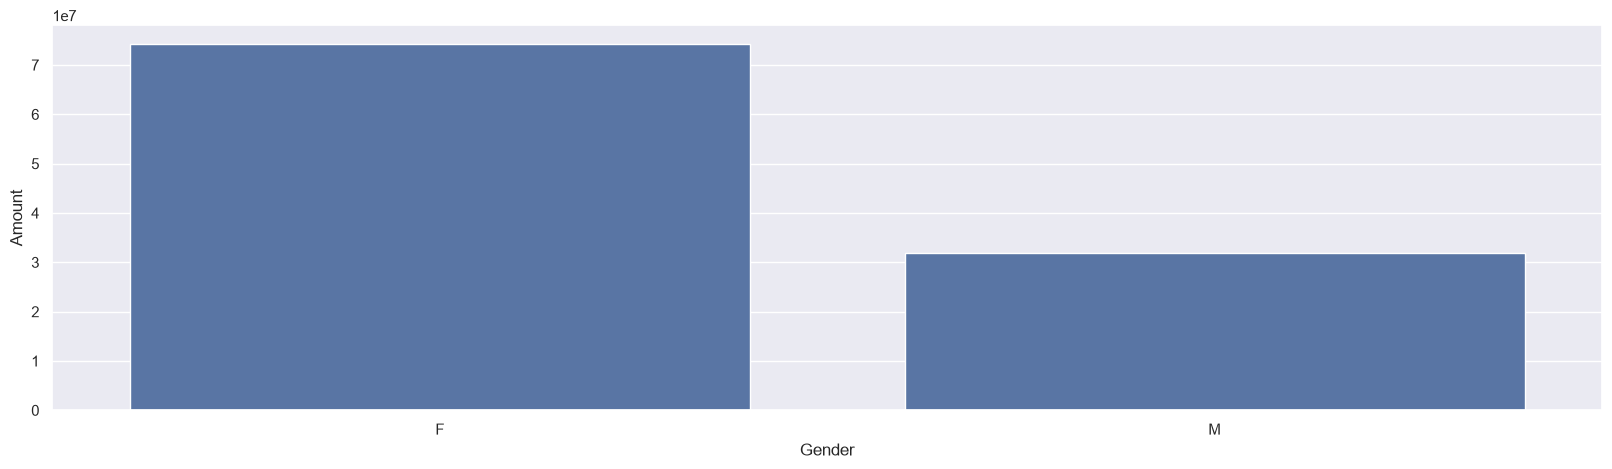

In [ ]:


sales_gen = df.groupby(['Gender'], as_index=False)['Amount'].sum().sort_values(by='Amount', ascending=False)

sns.barplot(x = 'Gender',y= 'Amount' ,data = sales_gen)

*From above graphs we can see that most of the buyers are females and even the purchasing power of females are greater than men*

##  Sales by Gender

This analysis compares total sales generated by different customer genders.

In [106]:
gender_sales = df.groupby('Gender')['Amount'].sum().sort_values(ascending=False)

print(gender_sales)

Gender
F    74335853
M    31913276
Name: Amount, dtype: int64


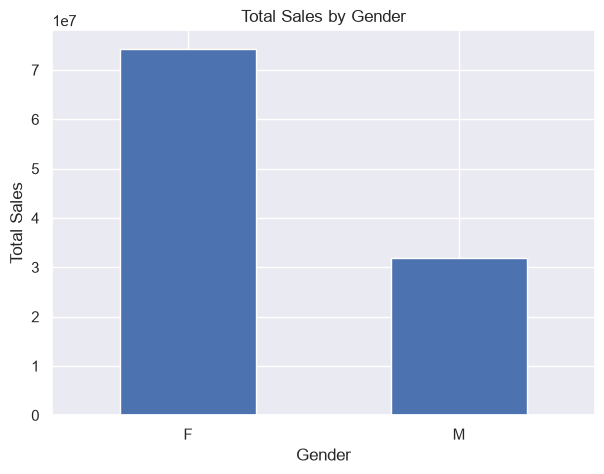

In [107]:
plt.figure(figsize=(7,5))

gender_sales.plot(kind='bar')

plt.title('Total Sales by Gender')
plt.xlabel('Gender')
plt.ylabel('Total Sales')
plt.xticks(rotation=0)

plt.show()

##  Orders by Gender

This analysis compares the number of orders placed by different customer genders.

In [108]:
gender_orders = df.groupby('Gender')['Orders'].sum().sort_values(ascending=False)

print(gender_orders)

Gender
F    19548
M     8433
Name: Orders, dtype: int64


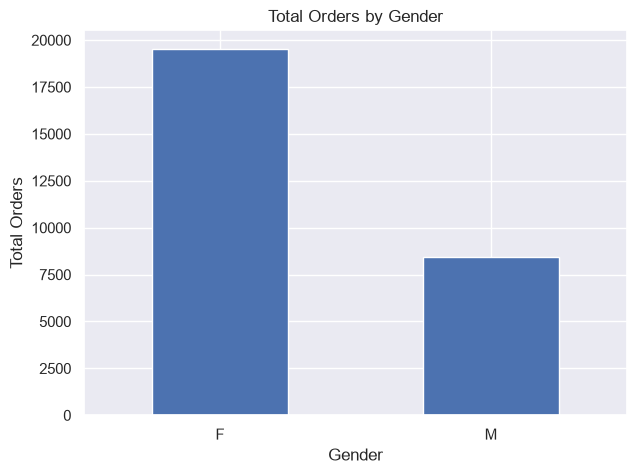

In [109]:
plt.figure(figsize=(7,5))

gender_orders.plot(kind='bar')

plt.title('Total Orders by Gender')
plt.xlabel('Gender')
plt.ylabel('Total Orders')
plt.xticks(rotation=0)

plt.show()

##  Age Group Analysis

This analysis examines purchasing behavior and sales performance across different customer age groups.### Age

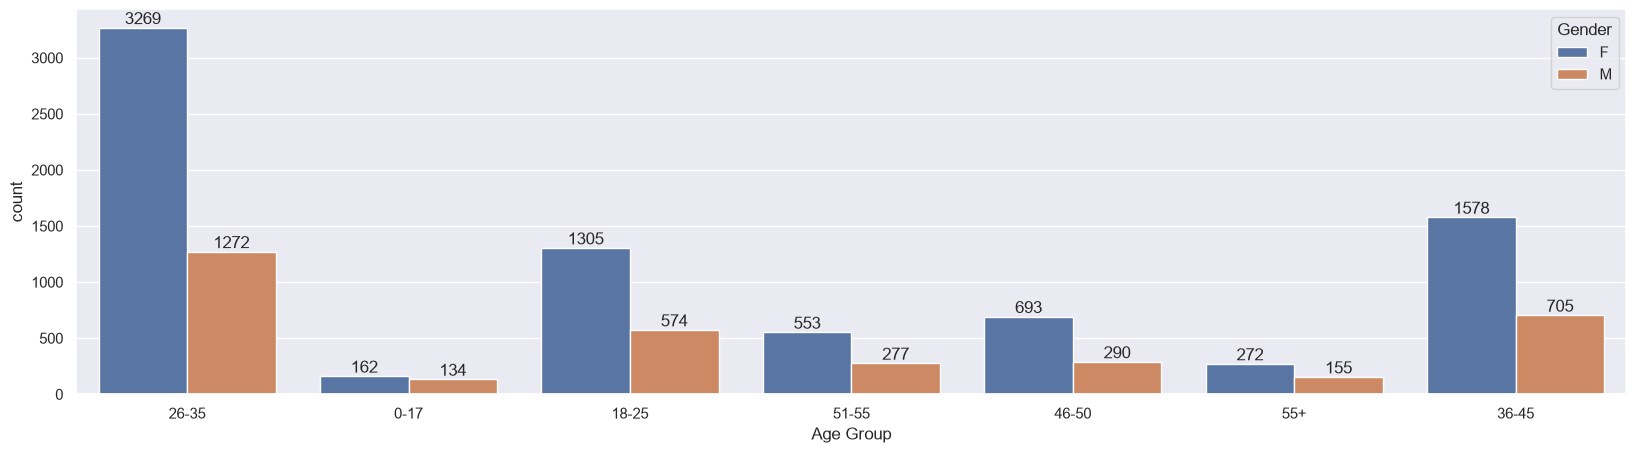

In [110]:
ax = sns.countplot(data = df, x = 'Age Group', hue = 'Gender')

for bars in ax.containers:
    ax.bar_label(bars)

<Axes: xlabel='Age Group', ylabel='Amount'>

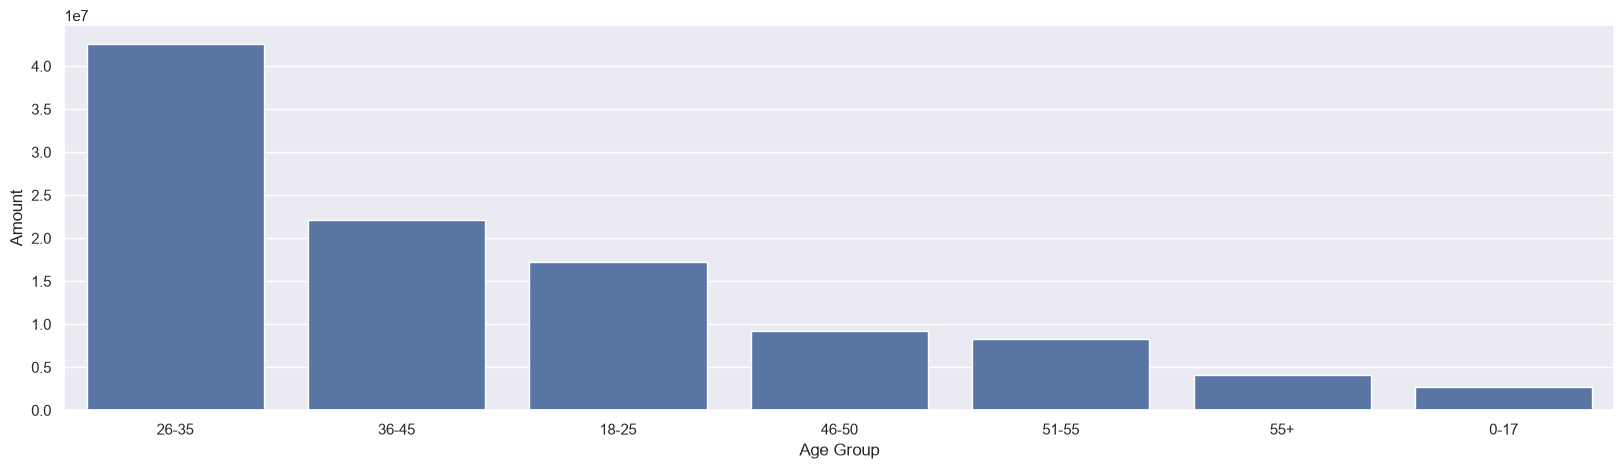

In [ ]:

sales_age = df.groupby(['Age Group'], as_index=False)['Amount'].sum().sort_values(by='Amount', ascending=False)

sns.barplot(x = 'Age Group',y= 'Amount' ,data = sales_age)

*From above graphs we can see that most of the buyers are of age group between 26-35 yrs female*

##  Sales by Age Group

This analysis compares total sales generated by different customer age groups.

In [112]:
age_sales = df.groupby('Age Group')['Amount'].sum().sort_values(ascending=False)

print(age_sales)

Age Group
26-35    42613442
36-45    22144994
18-25    17240732
46-50     9207844
51-55     8261477
55+       4080987
0-17      2699653
Name: Amount, dtype: int64


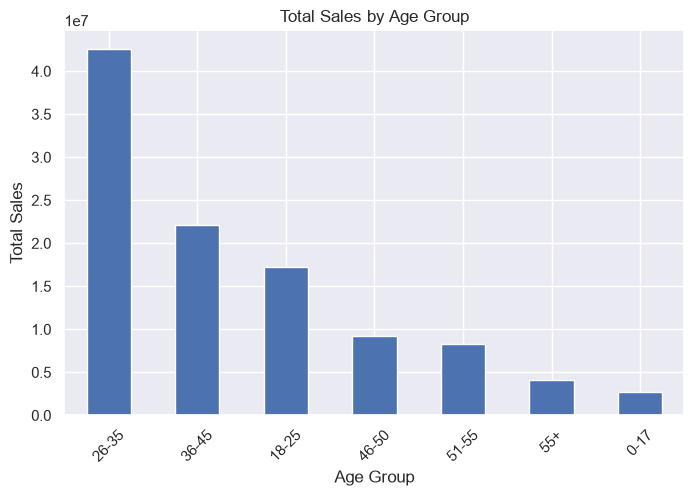

In [113]:
plt.figure(figsize=(8,5))

age_sales.plot(kind='bar')

plt.title('Total Sales by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Total Sales')
plt.xticks(rotation=45)

plt.show()

## State-wise Sales Analysis

This analysis compares total sales across different states and identifies the states contributing the most to overall sales.

<Axes: xlabel='State', ylabel='Orders'>

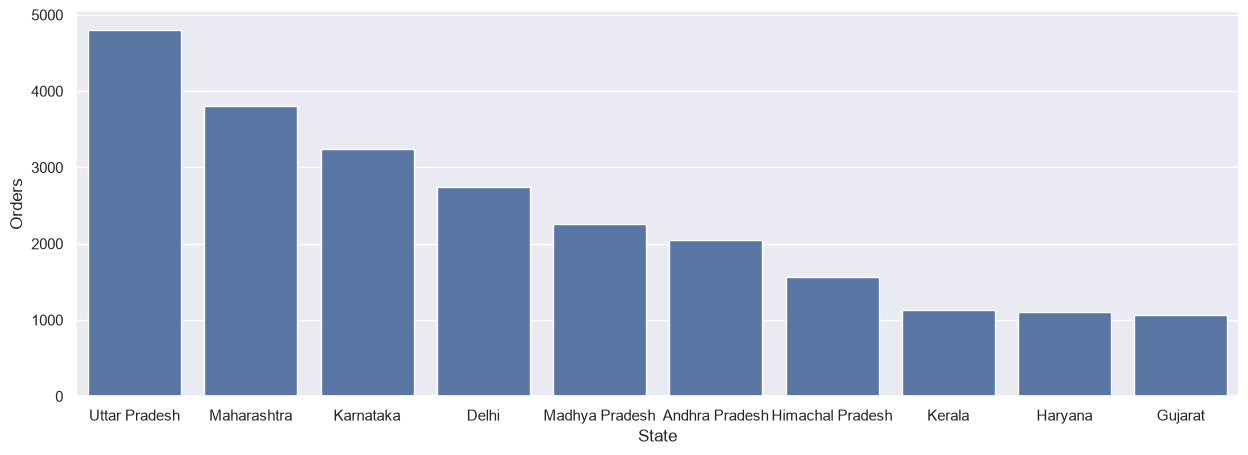

In [ ]:

sales_state = df.groupby(['State'], as_index=False)['Orders'].sum().sort_values(by='Orders', ascending=False).head(10)

sns.set(rc={'figure.figsize':(15,5)})
sns.barplot(data = sales_state, x = 'State',y= 'Orders')

<Axes: xlabel='State', ylabel='Amount'>

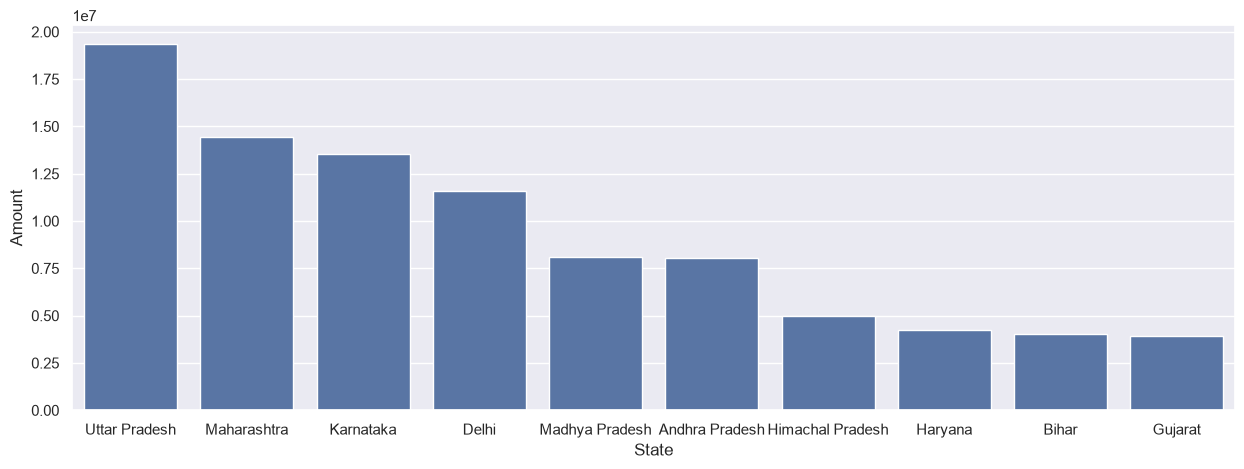

In [ ]:

sales_state = df.groupby(['State'], as_index=False)['Amount'].sum().sort_values(by='Amount', ascending=False).head(10)

sns.set(rc={'figure.figsize':(15,5)})
sns.barplot(data = sales_state, x = 'State',y= 'Amount')

*From above graphs we can see that most of the orders & total sales/amount are from Uttar Pradesh, Maharashtra and Karnataka respectively*


##  Sales by State

This analysis compares total sales generated across different states to identify the strongest geographic markets.

In [116]:
state_sales = df.groupby('State')['Amount'].sum().sort_values(ascending=False)

print(state_sales)

State
Uttar Pradesh       19374968
Maharashtra         14427543
Karnataka           13523540
Delhi               11603818
Madhya Pradesh       8101142
Andhra Pradesh       8037146
Himachal Pradesh     4963368
Haryana              4220175
Bihar                4022757
Gujarat              3946082
Kerala               3894491
Jharkhand            3026456
Uttarakhand          2520944
Rajasthan            1909409
Punjab               1525800
Telangana            1151490
Name: Amount, dtype: int64


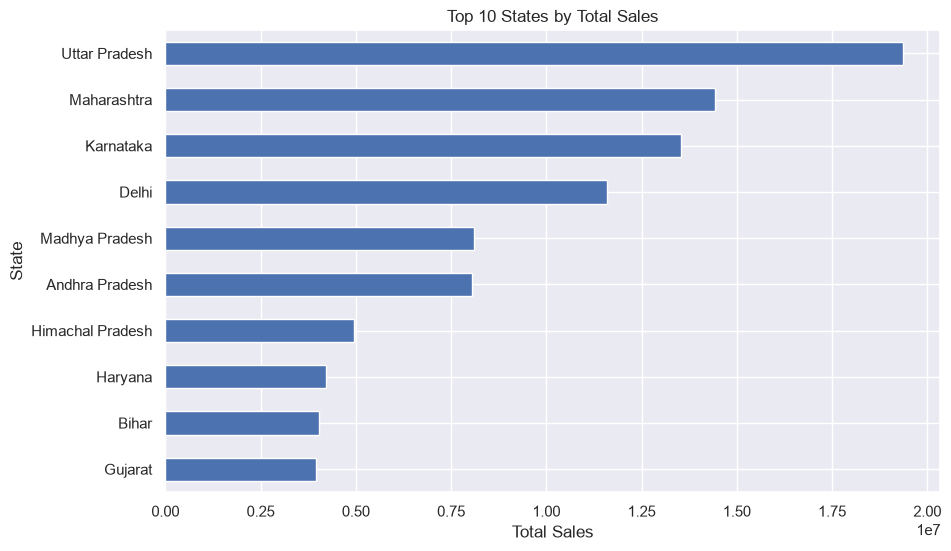

In [117]:
plt.figure(figsize=(10,6))

state_sales.head(10).sort_values().plot(kind='barh')

plt.title('Top 10 States by Total Sales')
plt.xlabel('Total Sales')
plt.ylabel('State')

plt.show()

##  Marital Status Analysis

This analysis examines sales performance across different marital-status groups to understand purchasing patterns within this customer segment.

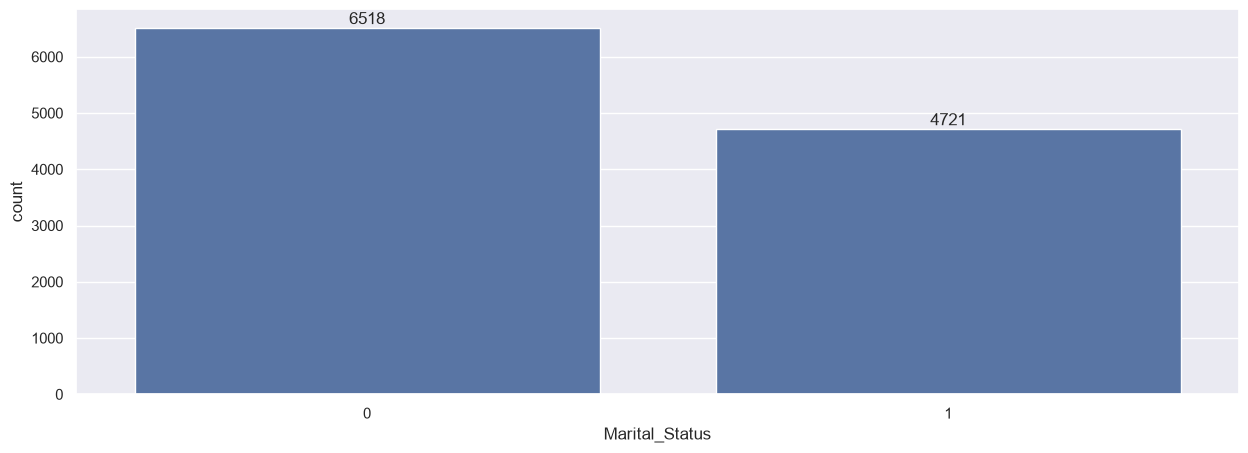

In [118]:
ax = sns.countplot(data = df, x = 'Marital_Status')

sns.set(rc={'figure.figsize':(7,5)})
for bars in ax.containers:
    ax.bar_label(bars)

<Axes: xlabel='Marital_Status', ylabel='Amount'>

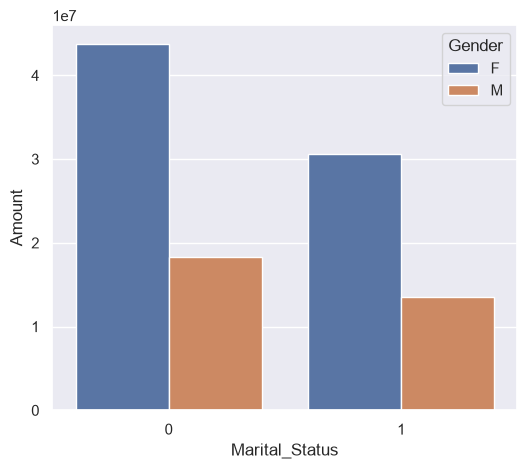

In [119]:
sales_state = df.groupby(['Marital_Status', 'Gender'], as_index=False)['Amount'].sum().sort_values(by='Amount', ascending=False)

sns.set(rc={'figure.figsize':(6,5)})
sns.barplot(data = sales_state, x = 'Marital_Status',y= 'Amount', hue='Gender')

*From above graphs we can see that most of the buyers are married (women) and they have high purchasing power*

##  Sales by Marital Status

This analysis compares total sales generated by customers based on their marital status.

In [120]:
marital_sales = df.groupby('Marital_Status')['Amount'].sum().sort_values(ascending=False)

print(marital_sales)

Marital_Status
0    62125384
1    44123745
Name: Amount, dtype: int64


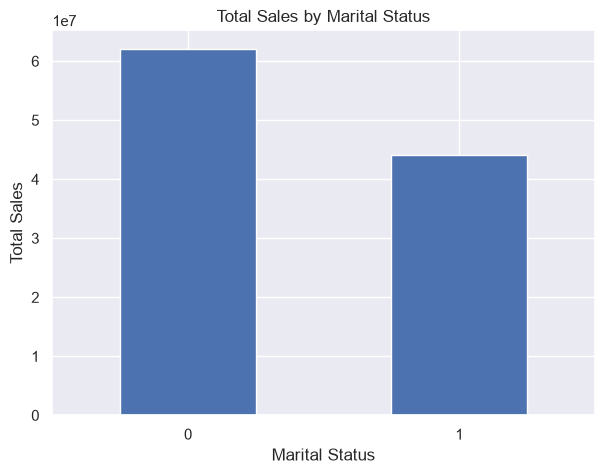

In [121]:
plt.figure(figsize=(7,5))

marital_sales.plot(kind='bar')

plt.title('Total Sales by Marital Status')
plt.xlabel('Marital Status')
plt.ylabel('Total Sales')
plt.xticks(rotation=0)

plt.show()

##  Occupation Analysis

This analysis examines sales performance across different occupational groups to understand purchasing patterns and identify the occupational segments contributing most to sales.

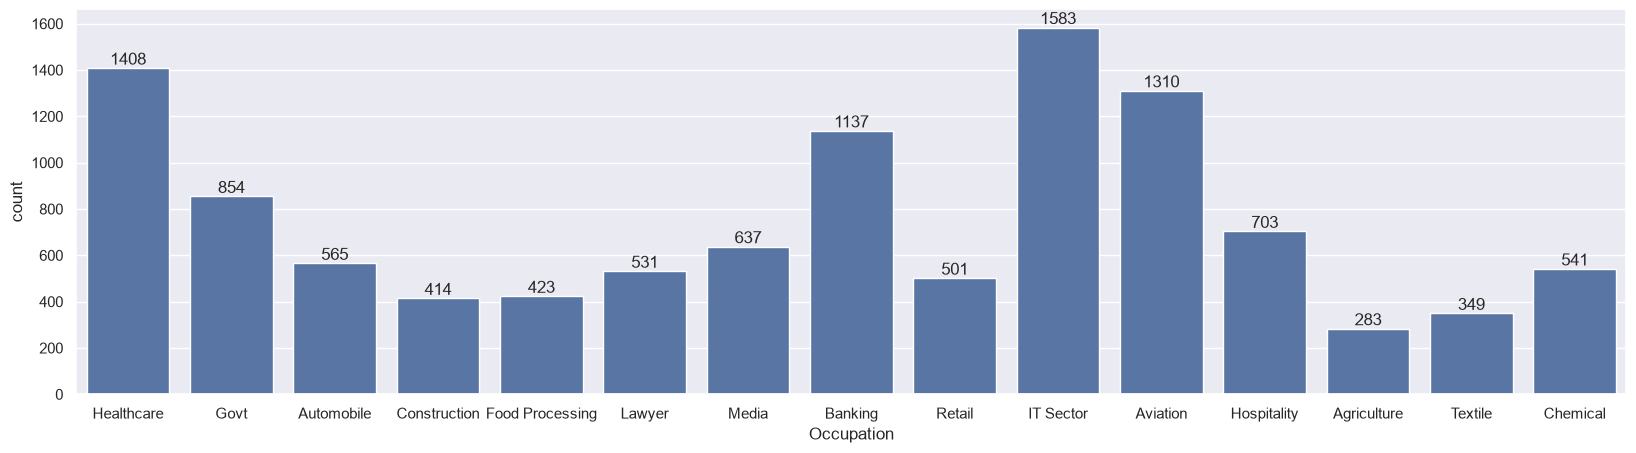

In [122]:
sns.set(rc={'figure.figsize':(20,5)})
ax = sns.countplot(data = df, x = 'Occupation')

for bars in ax.containers:
    ax.bar_label(bars)

<Axes: xlabel='Occupation', ylabel='Amount'>

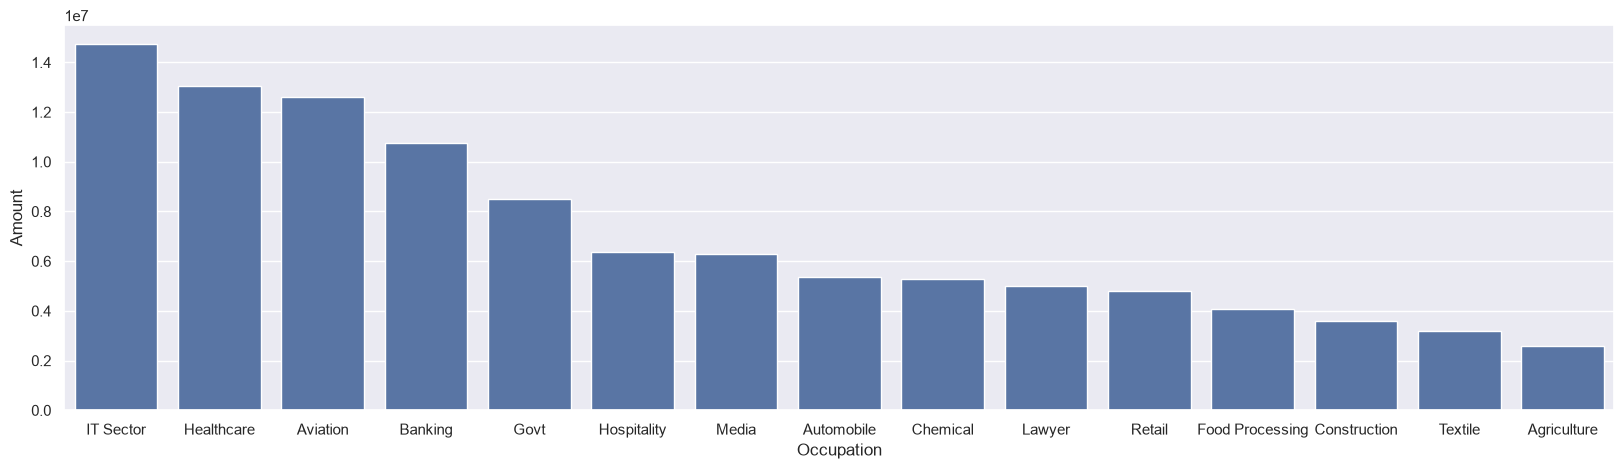

In [123]:
sales_state = df.groupby(['Occupation'], as_index=False)['Amount'].sum().sort_values(by='Amount', ascending=False)

sns.set(rc={'figure.figsize':(20,5)})
sns.barplot(data = sales_state, x = 'Occupation',y= 'Amount')

*From above graphs we can see that most of the buyers are working in IT, Healthcare and Aviation sector*

##  Sales by Occupation

This analysis compares total sales generated by customers from different occupational groups.

In [124]:
occupation_sales = df.groupby('Occupation')['Amount'].sum().sort_values(ascending=False)

print(occupation_sales)

Occupation
IT Sector          14755079
Healthcare         13034586
Aviation           12602298
Banking            10770610
Govt                8517212
Hospitality         6376405
Media               6295832
Automobile          5368596
Chemical            5297436
Lawyer              4981665
Retail              4783170
Food Processing     4070670
Construction        3597511
Textile             3204972
Agriculture         2593087
Name: Amount, dtype: int64


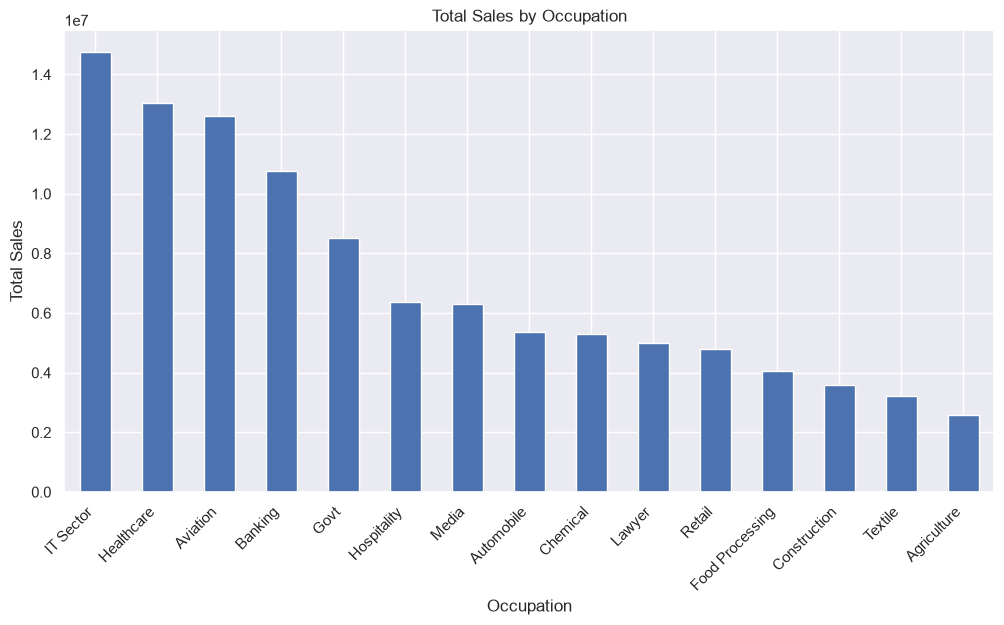

In [125]:
plt.figure(figsize=(12,6))

occupation_sales.plot(kind='bar')

plt.title('Total Sales by Occupation')
plt.xlabel('Occupation')
plt.ylabel('Total Sales')
plt.xticks(rotation=45, ha='right')

plt.show()

# Product Analysis

This section analyzes product performance to identify the categories and individual products that contribute most to overall sales.

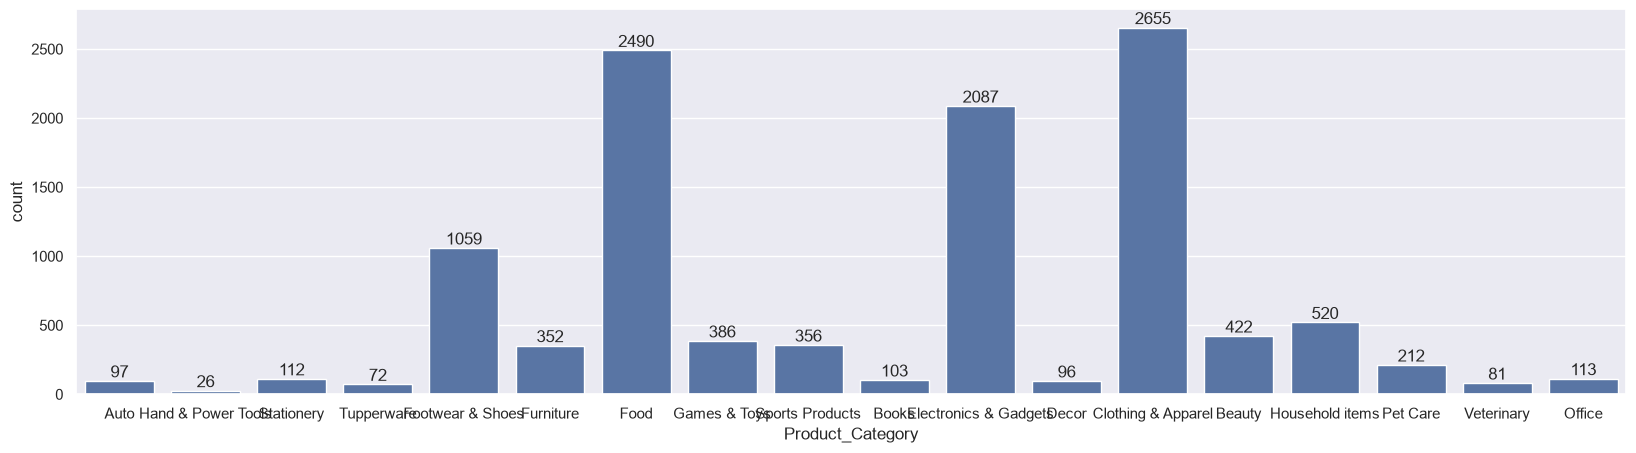

In [126]:
sns.set(rc={'figure.figsize':(20,5)})
ax = sns.countplot(data = df, x = 'Product_Category')

for bars in ax.containers:
    ax.bar_label(bars)

<Axes: xlabel='Product_Category', ylabel='Amount'>

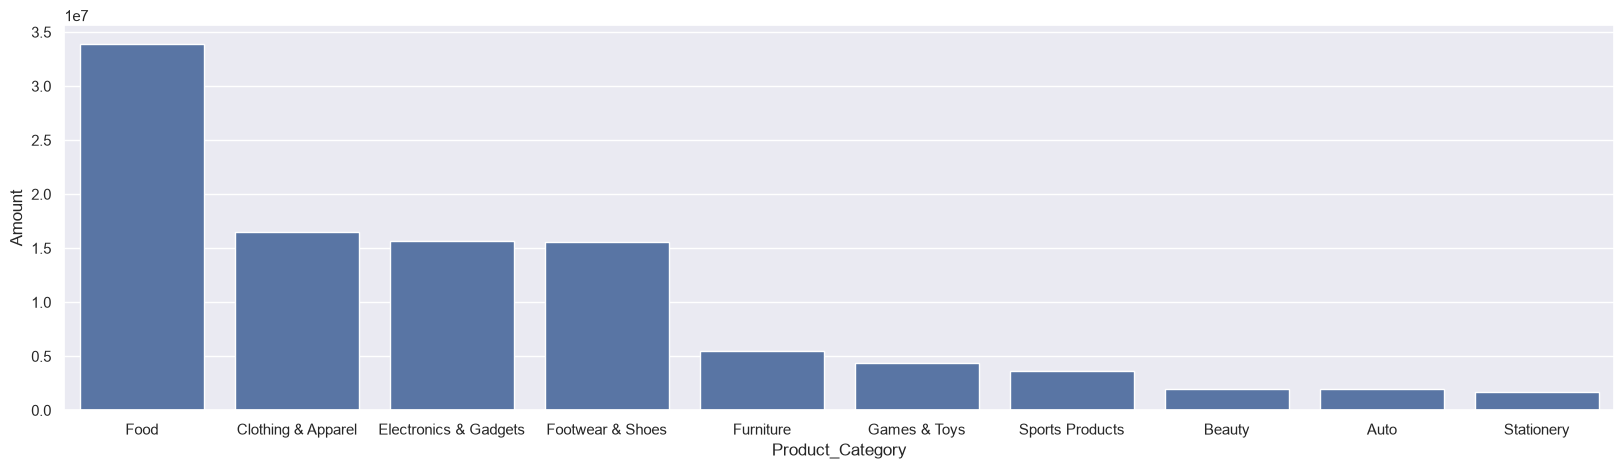

In [127]:
sales_state = df.groupby(['Product_Category'], as_index=False)['Amount'].sum().sort_values(by='Amount', ascending=False).head(10)

sns.set(rc={'figure.figsize':(20,5)})
sns.barplot(data = sales_state, x = 'Product_Category',y= 'Amount')

*From above graphs we can see that most of the sold products are from Food, Clothing and Electronics category*

<Axes: xlabel='Product_ID', ylabel='Orders'>

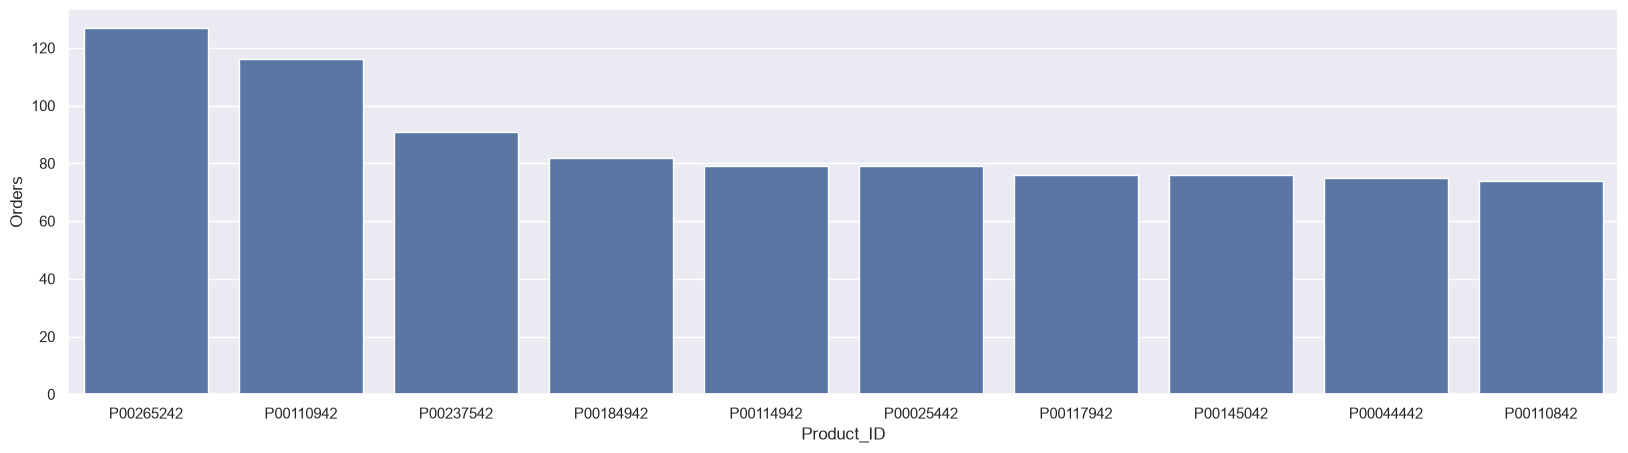

In [128]:
sales_state = df.groupby(['Product_ID'], as_index=False)['Orders'].sum().sort_values(by='Orders', ascending=False).head(10)

sns.set(rc={'figure.figsize':(20,5)})
sns.barplot(data = sales_state, x = 'Product_ID',y= 'Orders')

<Axes: xlabel='Product_ID'>

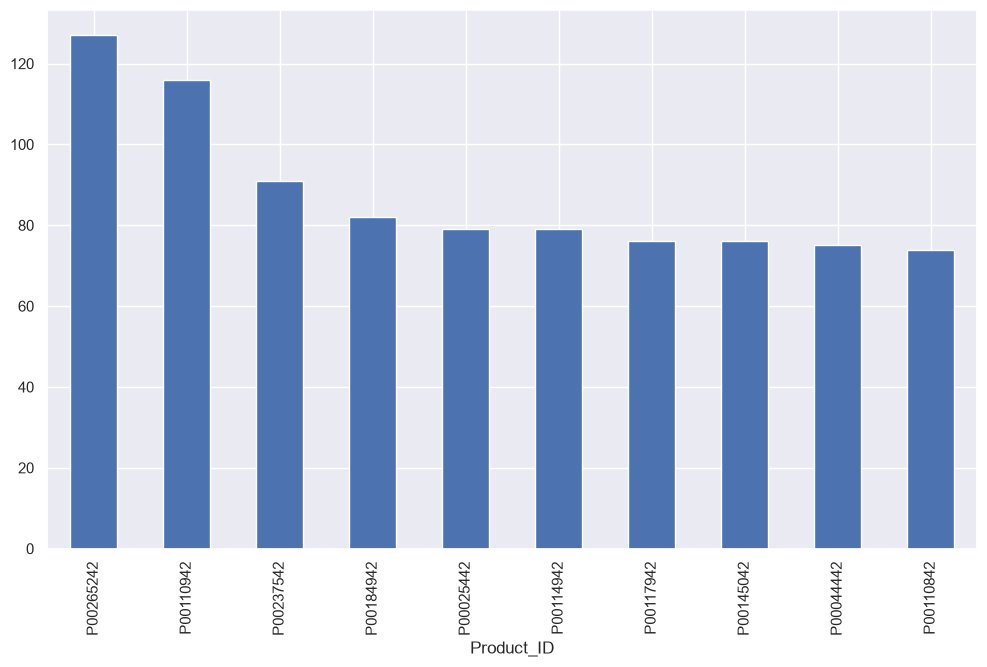

In [ ]:
fig1, ax1 = plt.subplots(figsize=(12,7))
df.groupby('Product_ID')['Orders'].sum().nlargest(10).sort_values(ascending=False).plot(kind='bar')

##  Sales by Product Category

This analysis compares total sales generated by different product categories.

In [130]:
category_sales = df.groupby('Product_Category')['Amount'].sum().sort_values(ascending=False)

print(category_sales)

Product_Category
Food                     33933883
Clothing & Apparel       16495019
Electronics & Gadgets    15643846
Footwear & Shoes         15575209
Furniture                 5440051
Games & Toys              4331694
Sports Products           3635933
Beauty                    1959484
Auto                      1958609
Stationery                1676051
Household items           1569337
Tupperware                1155642
Books                     1061478
Decor                      730360
Pet Care                   482277
Hand & Power Tools         405618
Veterinary                 112702
Office                      81936
Name: Amount, dtype: int64


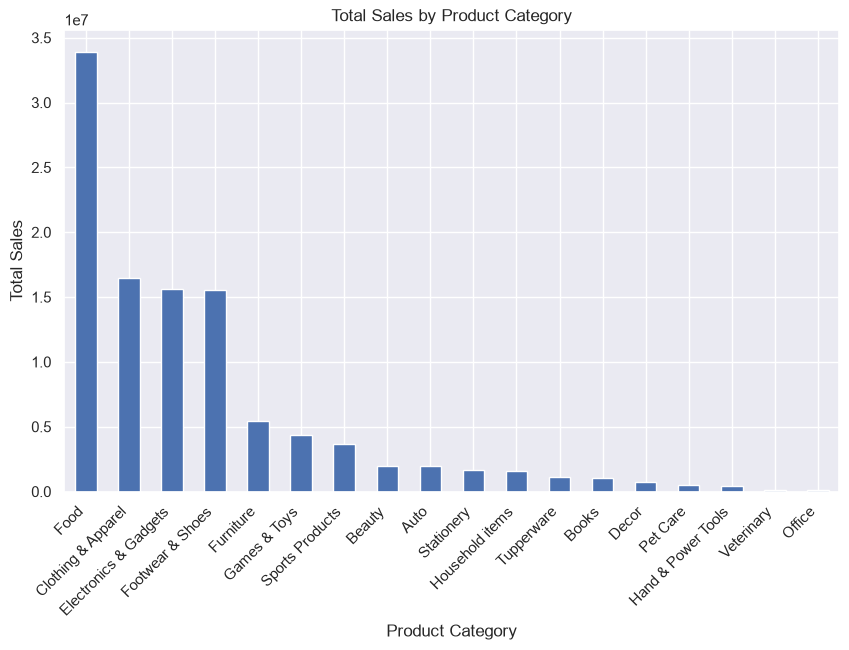

In [131]:
plt.figure(figsize=(10,6))

category_sales.plot(kind='bar')

plt.title('Total Sales by Product Category')
plt.xlabel('Product Category')
plt.ylabel('Total Sales')
plt.xticks(rotation=45, ha='right')

plt.show()

##  Top 10 Products by Sales

This analysis identifies the individual products that generated the highest total sales.

In [132]:
top_products = (
    df.groupby('Product_ID')['Amount']
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

print(top_products)

Product_ID
P00265242    540136
P00110942    424833
P00184942    401816
P00112142    341020
P00059442    338571
P00237542    322363
P00058042    307040
P00110742    294548
P00110842    290661
P00080342    283309
Name: Amount, dtype: int64


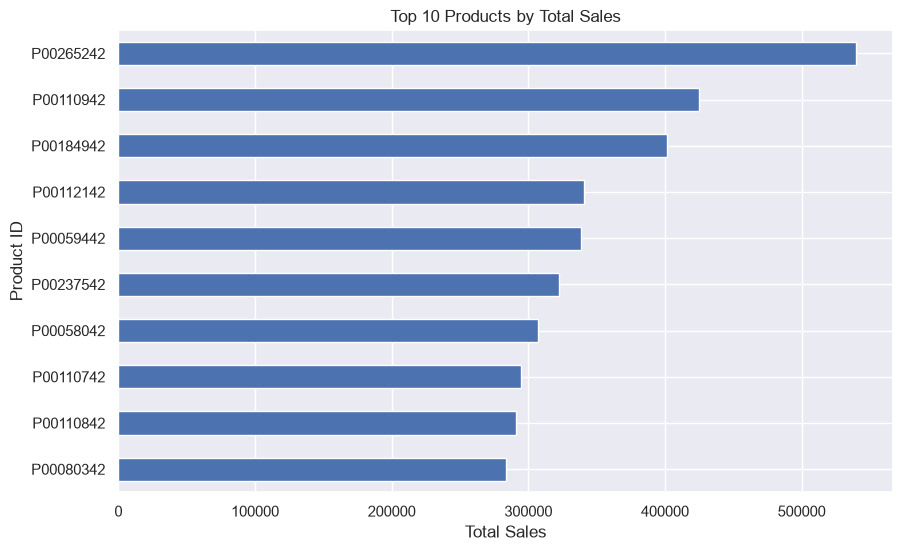

In [133]:
plt.figure(figsize=(10,6))

top_products.sort_values().plot(kind='barh')

plt.title('Top 10 Products by Total Sales')
plt.xlabel('Total Sales')
plt.ylabel('Product ID')

plt.show()

##  Sales by Age Group and Product Category

This analysis examines how purchasing patterns across product categories vary between different age groups.

In [134]:
age_category_sales = pd.pivot_table(
    df,
    values='Amount',
    index='Age Group',
    columns='Product_Category',
    aggfunc='sum'
)

age_category_sales

Product_Category,Auto,Beauty,Books,Clothing & Apparel,Decor,Electronics & Gadgets,Food,Footwear & Shoes,Furniture,Games & Toys,Hand & Power Tools,Household items,Office,Pet Care,Sports Products,Stationery,Tupperware,Veterinary
Age Group,,,,,,,,,,,,,,,,,,
0-17,56883.0,41129.0,10249.0,437011.0,7956.0,456666.0,1079989.0,78907.0,195373.0,107922.0,NaN,38221.0,3791.0,7056.0,118685.0,59419.0,NaN,396.0
18-25,350294.0,344387.0,201667.0,2962437.0,134052.0,2566454.0,6578809.0,647322.0,1047639.0,599476.0,89558.0,357601.0,16673.0,72957.0,697658.0,279187.0,276713.0,17848.0
26-35,895107.0,772381.0,424392.0,6568722.0,267972.0,6227399.0,13630823.0,6174879.0,2107141.0,1828425.0,163837.0,813609.0,31428.0,206758.0,1344602.0,779686.0,316539.0,59742.0
36-45,324520.0,364158.0,210697.0,3254060.0,163136.0,3143158.0,6237741.0,4551683.0,1058275.0,929677.0,99074.0,227996.0,16519.0,76379.0,831669.0,353012.0,283342.0,19898.0
46-50,79740.0,166313.0,96358.0,1450180.0,75765.0,1377937.0,2726781.0,1752933.0,443869.0,383395.0,NaN,67497.0,4252.0,71342.0,271877.0,85821.0,145952.0,7832.0
51-55,172663.0,190158.0,81421.0,1196558.0,43078.0,1317082.0,2315333.0,1643691.0,392170.0,320418.0,23434.0,43570.0,4533.0,33748.0,273728.0,89133.0,116253.0,4506.0
55+,79402.0,80958.0,36694.0,626051.0,38401.0,555150.0,1364407.0,725794.0,195584.0,162381.0,29715.0,20843.0,4740.0,14037.0,97714.0,29793.0,16843.0,2480.0


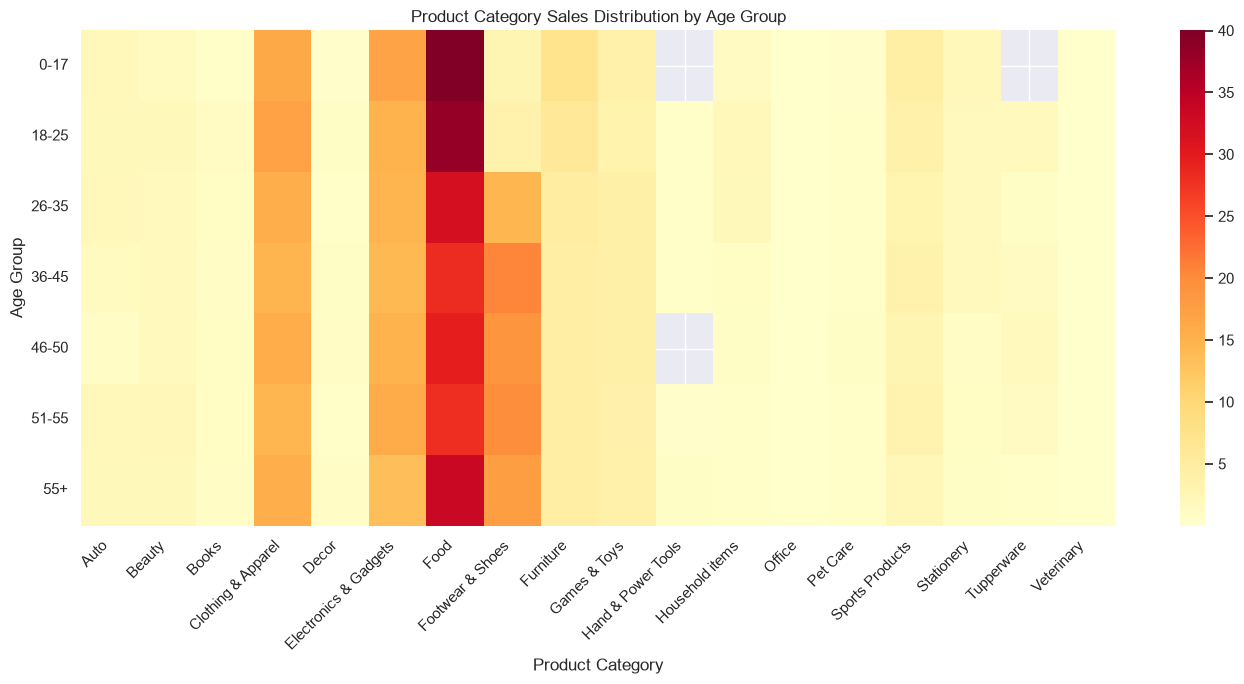

In [ ]:
age_category_percentage = (
    age_category_sales.div(age_category_sales.sum(axis=1), axis=0) * 100
)

plt.figure(figsize=(14,7))

sns.heatmap(
    age_category_percentage,
    annot=False,
    cmap='YlOrRd'
)

plt.title('Product Category Sales Distribution by Age Group')
plt.xlabel('Product Category')
plt.ylabel('Age Group')

plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

#  Key Business Insights

The analysis of the Diwali sales dataset reveals several patterns in customer behavior, geographic performance, and product demand.


In [136]:
print("Top Gender by Sales:")
print(gender_sales.idxmax(), "-", gender_sales.max())

print("\nTop Age Group by Sales:")
print(age_sales.idxmax(), "-", age_sales.max())

print("\nTop Marital Status by Sales:")
print(marital_sales.idxmax(), "-", marital_sales.max())

print("\nTop Occupation by Sales:")
print(occupation_sales.idxmax(), "-", occupation_sales.max())

print("\nTop State by Sales:")
print(state_sales.idxmax(), "-", state_sales.max())

print("\nTop Product Category by Sales:")
print(category_sales.idxmax(), "-", category_sales.max())

print("\nTop Product by Sales:")
print(top_products.idxmax(), "-", top_products.max())

Top Gender by Sales:
F - 74335853

Top Age Group by Sales:
26-35 - 42613442

Top Marital Status by Sales:
0 - 62125384

Top Occupation by Sales:
IT Sector - 14755079

Top State by Sales:
Uttar Pradesh - 19374968

Top Product Category by Sales:
Food - 33933883

Top Product by Sales:
P00265242 - 540136


##  Key Findings

- **Gender:** The analysis shows that the highest sales were generated by female customers, with total sales of 7,43,35,853.
- **Age Group:** 26-35 age group generated the highest total sales, with total sales of 4,26,13,442.
- **Marital Status:** married customers generated the highest total sales, with total sales of 6,21,25,384.
- **Occupation:** IT sector generated the highest total sales, with total sales of 1,47,55,079.
- **State:** Uttar Pradesh generated the highest total sales, with total sales of 1,93,74,968.
- **Product Category:** Food generated the highest total sales, with total sales of 3,39,33,883.
- **Products:** P0026542 generated the highest total sales, with total sales of 5,40,136.

##  Business Insights

- The analysis highlights the customer segments that contribute most significantly to overall sales.
- The sales distribution across age groups provides an indication of which customer age segments show stronger purchasing activity.
- Differences in sales across occupations and marital-status groups reveal variations in customer purchasing behavior.
- State-wise analysis helps identify the geographic markets contributing most to overall sales.
- Product category and individual product analysis highlights areas of stronger product demand.
- The relationship between age groups and product categories provides additional insight into differences in purchasing preferences across customer segments.